<a href="https://colab.research.google.com/github/Kavia-M/Data_science_course-Intellipaat/blob/main/Python/Classwork/Trainers_notes/Machine_Learning/Time_Series_Prefilled_Aisha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df =pd.read_csv("AirPassengers.csv")

In [ ]:
df  #we have to forcaste next 12 months paasengers count based on the data provided

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [ ]:
df.shape

(144, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [ ]:
#converting the months column to datetime format
df['Month']=pd.to_datetime(df['Month'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [ ]:
df

,Month,#Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [ ]:
df.isnull().sum()

,0
Month,0
#Passengers,0


In [ ]:
df.duplicated().sum()

0

In [ ]:
df.index

RangeIndex(start=0, stop=144, step=1)

In [ ]:
df.index=df['Month']

In [ ]:
df

,Month,#Passengers
Month,,
1949-01-01,1949-01-01,112
1949-02-01,1949-02-01,118
1949-03-01,1949-03-01,132
1949-04-01,1949-04-01,129
1949-05-01,1949-05-01,121
...,...,...
1960-08-01,1960-08-01,606
1960-09-01,1960-09-01,508
1960-10-01,1960-10-01,461


In [ ]:
del df['Month']

In [ ]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   #Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


<Axes: xlabel='Month'>

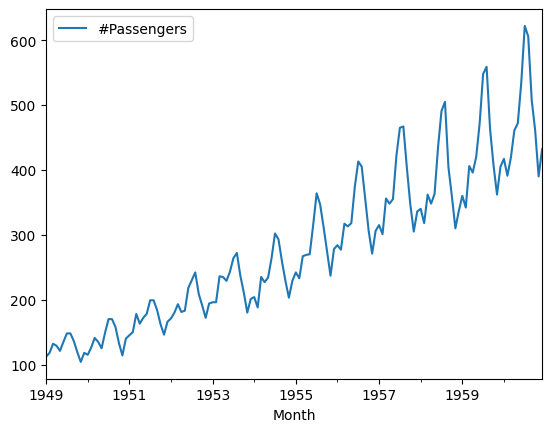

In [ ]:
df.plot()
# mean and std dev should be constant throughout for a graph to be stationary

In [ ]:
# Adfuller  --> test to check the stationarity of the series
# null hypo = data is stationary
# alternate hypo = data is not stationary

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
result =adfuller(df['#Passengers'])

In [ ]:
result

#adfuller test gives you multiple outputs out of which we need only index 1(p value), rest you'll study in ai

(0.8153688792060498,
 0.991880243437641,
 13,
 130,
 {'1%': -3.4816817173418295,
  '5%': -2.8840418343195267,
  '10%': -2.578770059171598},
 996.692930839019)

In [ ]:
p_val=result[1]
p_val

0.991880243437641

In [ ]:
if(p_val<0.05):
  print("we accept the null hypo - data is stationary")
else:
  print("we reject the null hypo - data is not stationary")

we reject the null hypo - data is not stationary


In [ ]:
#as the data is not stationary we should apply de trent or transformation

# Rolling mean (or moving average) is just an average of a sliding window of values.
# Example: if you want a 12-month rolling mean, then for each month you look at the previous 12 months, take their average, and assign it as the “rolling mean” for that month.
# It “smooths out” the trend and seasonality by showing the overall movement, instead of month-to-month noise.

# Instead of looking at your weight every single day (which goes up and down), you look at your average weight of the past 12 days to see the trend more clearly

In [ ]:
# ARIMA requires the data to be stationary → meaning the mean and variance do not change over time.
# The Air Passengers dataset shows an upward trend (passengers increase every year).
# To remove this trend, we subtract the rolling mean from the original data.
# This is called detrending.

rolling_mean=df.rolling(window=12).mean() #taking 12 months period since data is monthly, we can take anything as long as the data is being stationarized
rolling_mean_detrened=df-rolling_mean
# Subtract the rolling mean from the actual passenger values.
# This removes the trend → leaves behind a series that fluctuates around (constant line)mean.

In [ ]:
rolling_mean_detrened.head(15)


,#Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
1949-06-01,NaN
1949-07-01,NaN
1949-08-01,NaN
1949-09-01,NaN


<Axes: title={'center': 'original data'}, xlabel='Month'>

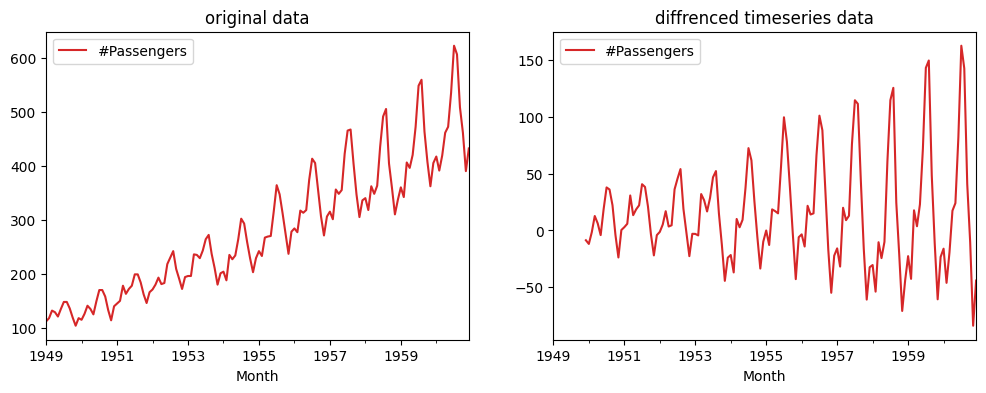

In [ ]:
ax1=plt.subplot(1,2,2)
rolling_mean_detrened.plot(figsize=(12,4),color='tab:red',
                           title="diffrenced timeseries data",
                           ax=ax1)

ax2=plt.subplot(1,2,1)
df.plot(figsize=(12,4),color='tab:red',title="original data",ax=ax2)

In [ ]:
detrended_data=rolling_mean_detrened.dropna() #smaller dataset made out of detrended data

In [ ]:
detrended_data

,#Passengers
Month,
1949-12-01,-8.666667
1950-01-01,-11.916667
1950-02-01,-1.583333
1950-03-01,12.666667
1950-04-01,6.166667
...,...
1960-08-01,142.666667
1960-09-01,40.916667
1960-10-01,-10.583333


In [ ]:
result=adfuller(detrended_data['#Passengers'])

In [ ]:
p_val=result[1]
p_val

0.022104139473878875

In [ ]:
if(p_val<0.05):
  print("we accept the null hypo - data is stationary")
else:
  print("we reject the null hypo - data is not stationary")

we accept the null hypo - data is stationary


In [ ]:
m=detrended_data.rolling(window=12).mean()
s=detrended_data.rolling(window=12).std()

Text(0.5, 1.0, 'detrended data with mean and std line')

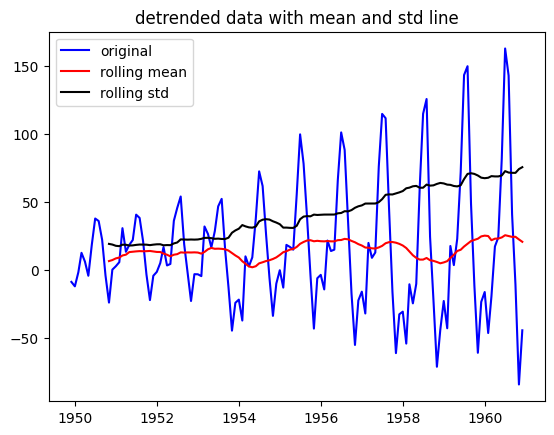

In [ ]:
plt.plot(detrended_data,color='blue',label='original')
plt.plot(m,color='red',label='rolling mean')
plt.plot(s,color="black",label="rolling std")
plt.legend(loc='best')
plt.title("detrended data with mean and std line")

In [ ]:
# Spllitting the dtaa in train nad test
train=detrended_data[:120]['#Passengers']  #taking 10years of data for training
test=detrended_data[120:]['#Passengers']  #taking 1 year data for the testing

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
model=ARIMA(train,order=(1,0,2))    #order=(p=AR,d=Differencing,q=MA)  IF D=0 no need to deal with trends else D=1 then deal with the trends

model_fit=model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
# detrended_data['Predict'] =model_fit.predict(start=120,end=132)

In [ ]:
detrended_data['Predict'] =model_fit.predict(start=len(train),end=len(train)+len(test)-1)

/tmp/ipython-input-10813269.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  detrended_data['Predict'] =model_fit.predict(start=len(train),end=len(train)+len(test)-1)


In [ ]:
detrended_data.tail(12)

,#Passengers,Predict
Month,,
1960-01-01,-16.083333,-13.402469
1960-02-01,-46.166667,1.206088
1960-03-01,-19.250000,7.831010
1960-04-01,17.333333,10.835386
1960-05-01,24.000000,12.197859
1960-06-01,81.750000,12.815735
1960-07-01,162.583333,13.095940
1960-08-01,142.666667,13.223011
1960-09-01,40.916667,13.280638


<Axes: xlabel='Month'>

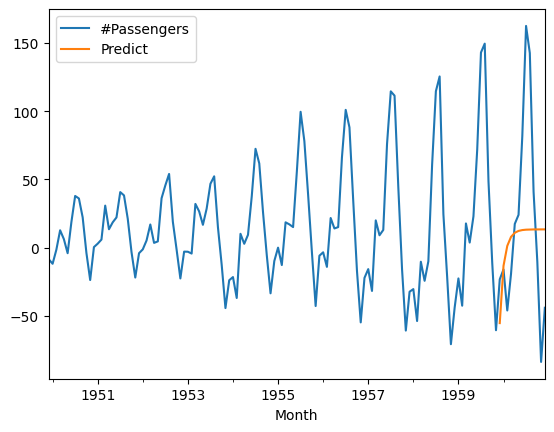

In [ ]:
detrended_data[['#Passengers','Predict']].plot()

In [ ]:
import numpy as np
print(np.__version__)


1.26.4


In [ ]:
# !pip install numpy==1.26.4 pmdarima==2.0.4
#run this and restart the session and comment the above line and runa ll the cells again

In [ ]:
# AuttoARima --> it will five the best model out of the time series model according to your dataset


In [ ]:
from pmdarima import auto_arima
#colab updated and they've not linked suprise library with the latest version of numpy so we will downgrade Numpy version

In [ ]:
auto=auto_arima(detrended_data['#Passengers'])  # helps to pick the best model based on data

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12

In [ ]:
auto.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  133
Model:               SARIMAX(3, 0, 2)   Log Likelihood                -612.905
Date:                Mon, 15 Sep 2025   AIC                           1239.810
Time:                        17:49:27   BIC                           1260.043
Sample:                    12-01-1949   HQIC                          1248.032
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      6.8579      1.701      4.033      0.000       3.525      10.191
ar.L1          0.8625      0.171      5.045      0.000       0.527       1.198
ar.L2          0.2071      0.236      0.878      0.380      -0.255       0.670
ar.L3         -0.5239      0.142     -3.683      0.000      -0.803      -0.245
ma.L1          0.0684      0.138      0.496      0.620      -0.202       0.338
ma.L2         -0.7564      0.091     -8.293      0.000      -0.935      -0.578
sigma2       577.4776     71.847      8.038      0.000     436.660     718.295
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 8.11
Prob(Q):                              0.89   Prob(JB):                         0.02
Heteroskedasticity (H):               6.21   Skew:                             0.56
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.48
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
#Acoording to autoarima SARIMAX(3,0,2) is the best model for the the given dataset

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
model=SARIMAX(train,order=(3,0,2),seasonal_order=(3,0,2,12)) #every 12 months pattern in repeting
model=model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary star

In [ ]:
detrended_data['Predict'] =model.predict(start=len(train),end=len(train)+len(test)-1)


/tmp/ipython-input-1317917095.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  detrended_data['Predict'] =model.predict(start=len(train),end=len(train)+len(test)-1)


<Axes: xlabel='Month'>

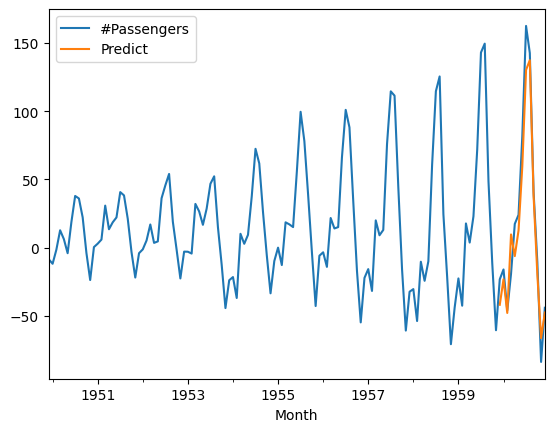

In [ ]:
detrended_data[['#Passengers','Predict']].plot()

In [ ]:
forecast=model.forecast(steps=48)  #48=len(len(x_test)+future)

In [ ]:
forecast

,predicted_mean
1959-12-01,-42.011668
1960-01-01,-23.325939
1960-02-01,-47.993742
1960-03-01,9.597506
1960-04-01,-6.280826
1960-05-01,12.567501
1960-06-01,59.636339
1960-07-01,130.324231
1960-08-01,137.468830
1960-09-01,38.187274


<Axes: xlabel='Month'>

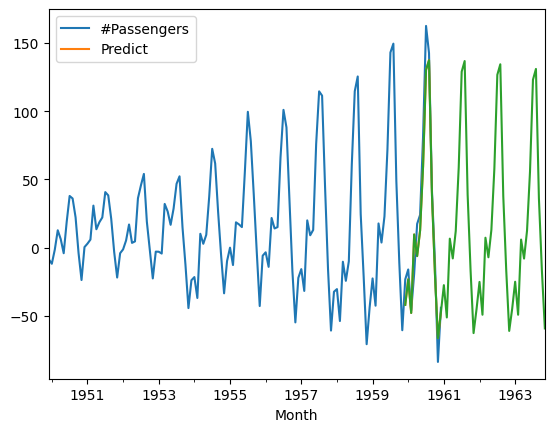

In [ ]:
detrended_data.plot()
forecast.plot()

In [ ]:
# sc=stand()
# x=scaled

# y_pred_scaled=model.predict(x_test_sclaed)
# y_or=sc.inver_transform()

In [ ]:
# np.exp(y_forcat)

##Mean transformation
# rolling_mean=df.rolling(window=12).mean()
# rolling_mean_detrened=df-rolling_mean

# df_copy=rolling_mean_detrened.copy()

In [ ]:
# y_pred_cal=model.predict(x_test)
# y_pred_cal